In [61]:
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
from langgraph.graph import MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from langgraph.constants import START, END

load_dotenv()

True

In [62]:
store = InMemoryStore()
userId = "u1"

user_details_namespace = ("user",userId,"details")

store.put(user_details_namespace, "profile_1", {"data": "Name: Nitish"})
store.put(user_details_namespace, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details_namespace, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details_namespace, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details_namespace, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [63]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Dhairya...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [64]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [65]:


from langchain_core.messages import SystemMessage


def chat_node(state:MessagesState,config:RunnableConfig,store: BaseStore):
    userId = config["configurable"]["userId"]
    user_details_namespace = ("user", userId, "details")
    store_items = store.search(user_details_namespace)

    if store_items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in store_items)
    else:
        user_details_content = ""

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_details_content)
    system_msg = SystemMessage(content=system_prompt)
    print("================================================")
    print(system_msg)
    print("================================================")

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}



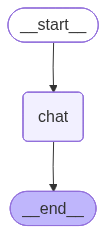

In [66]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile(store=store)
graph

In [67]:
config = {"configurable":{"userId":"u1"}}
graph.invoke({"messages":[{"role": "user", "content": "Explain gen ai in simple terms."}]},config=config)

content='You are a helpful assistant with memory capabilities.\nIf user-specific memory is available, use it to personalize\nyour responses based on what you know about the user.\n\nYour goal is to provide relevant, friendly, and tailored\nassistance that reflects the user’s preferences, context, and past interactions.\n\nIf the user’s name or relevant personal context is available, always personalize your responses by:\n    – Always Address the user by name (e.g., "Sure, Dhairya...") when appropriate\n    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")\n    – Adjusting the tone to feel friendly, natural, and directly aimed at the user\n\nAvoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."\nsay "Since your project is built with TypeScript..."\n\nUse personalization especially in:\n    – Greetings and transitions\n    – Help or guidance tailored to tools and frameworks the user uses\

{'messages': [HumanMessage(content='Explain gen ai in simple terms.', additional_kwargs={}, response_metadata={}, id='10338e7a-e401-49c4-90f6-8cded1e15aa7'),
  AIMessage(content='Sure, Nitish—here’s a quick, Python‑flavored rundown of generative AI.\n\n---\n\n### What is Generative AI?\n\n* **Goal:** Create new content (text, images, code, music, etc.) that looks or sounds like it was made by a human.  \n* **How it works:** A model learns patterns from a large dataset and then *samples* from those patterns to produce fresh outputs.\n\nThink of it as a super‑smart autocomplete that can continue a story, draw a picture, or even write a function you haven’t seen before.\n\n---\n\n### Simple Analogy\n\nImagine you read thousands of recipes. Afterward, you could invent a brand‑new dish by mixing the ingredients and steps you’ve seen. Generative AI does the same, but with math instead of a human brain.\n\n---\n\n### Tiny Python Demo (using `transformers`)\n\n```python\nfrom transformers impo